In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv("../../data_raw/SG.csv")

In [15]:
df.head()

,location_key,date,place_id,wikidata_id,datacommons_id,country_code,country_name,iso_3166_1_alpha_2,iso_3166_1_alpha_3,aggregation_level,...,search_trends_wheeze,search_trends_xeroderma,search_trends_xerostomia,search_trends_yawn,average_temperature_celsius,minimum_temperature_celsius,maximum_temperature_celsius,rainfall_mm,dew_point,relative_humidity
0,SG,2020-01-01,ChIJdZOLiiMR2jERxPWrUs9peIg,Q334,country/SGP,SG,Singapore,SG,SGP,0,...,0.30,4.45,0.46,0.25,27.816667,25.400000,31.444444,0.406400,23.622222,78.160465
1,SG,2020-01-02,ChIJdZOLiiMR2jERxPWrUs9peIg,Q334,country/SGP,SG,Singapore,SG,SGP,0,...,0.31,4.33,0.44,0.19,27.483333,25.116667,30.522222,1.213556,24.072222,81.775103
2,SG,2020-01-03,ChIJdZOLiiMR2jERxPWrUs9peIg,Q334,country/SGP,SG,Singapore,SG,SGP,0,...,0.28,4.40,0.40,0.21,27.627778,25.266667,31.172222,0.793750,24.255556,82.004853
3,SG,2020-01-04,ChIJdZOLiiMR2jERxPWrUs9peIg,Q334,country/SGP,SG,Singapore,SG,SGP,0,...,0.29,4.78,0.42,0.21,27.200000,24.700000,30.883333,1.682750,23.800000,81.865993
4,SG,2020-01-05,ChIJdZOLiiMR2jERxPWrUs9peIg,Q334,country/SGP,SG,Singapore,SG,SGP,0,...,0.28,4.44,0.41,0.24,27.744444,24.811111,31.872222,0.431800,23.477778,77.721261


In [4]:
dates_idx: list[int] = []

for i, date in enumerate(df.date):
    if date[5:7] in {'01', '04', '07', '10'} and date[8:] == '01':
        dates_idx.append(i)

In [5]:
for col in df.columns:
    print(col) if "search" not in col else None

date
new_confirmed
new_deceased
new_tested
cumulative_confirmed
cumulative_deceased
new_persons_vaccinated
cumulative_persons_vaccinated
new_persons_fully_vaccinated
cumulative_persons_fully_vaccinated
new_vaccine_doses_administered
cumulative_vaccine_doses_administered
population
population_male
population_female
population_rural
population_urban
population_largest_city
population_clustered
population_density
human_development_index
population_age_00_09
population_age_10_19
population_age_20_29
population_age_30_39
population_age_40_49
population_age_50_59
population_age_60_69
population_age_70_79
population_age_80_and_older
gdp_usd
gdp_per_capita_usd
human_capital_index
area_sq_km
area_rural_sq_km
area_urban_sq_km
life_expectancy
smoking_prevalence
diabetes_prevalence
infant_mortality_rate
adult_male_mortality_rate
adult_female_mortality_rate
pollution_mortality_rate
comorbidity_mortality_rate
hospital_beds_per_1000
nurses_per_1000
physicians_per_1000
health_expenditure_usd
out_of_po

In [6]:
for col in sorted(df.columns):
    print(col) if "search" in col else None

search_trends_abdominal_obesity
search_trends_abdominal_pain
search_trends_acne
search_trends_actinic_keratosis
search_trends_acute_bronchitis
search_trends_adrenal_crisis
search_trends_ageusia
search_trends_alcoholism
search_trends_allergic_conjunctivitis
search_trends_allergy
search_trends_amblyopia
search_trends_amenorrhea
search_trends_amnesia
search_trends_anal_fissure
search_trends_anaphylaxis
search_trends_anemia
search_trends_angina_pectoris
search_trends_angioedema
search_trends_angular_cheilitis
search_trends_anosmia
search_trends_anxiety
search_trends_aphasia
search_trends_aphonia
search_trends_apnea
search_trends_arthralgia
search_trends_arthritis
search_trends_ascites
search_trends_asperger_syndrome
search_trends_asphyxia
search_trends_asthma
search_trends_astigmatism
search_trends_ataxia
search_trends_atheroma
search_trends_attention_deficit_hyperactivity_disorder
search_trends_auditory_hallucination
search_trends_autoimmune_disease
search_trends_avoidant_personality_diso

In [8]:
from matplotlib.axes import Axes

In [9]:
def plot_scatter_on_ax(ax: Axes, df: pd.DataFrame, name_column: str) -> None:
    ax.plot(df["date"], df[name_column], label = name_column)

def configure_axis(ax: Axes, ) -> None:
    ax.set_xticks([df.date[i] for i in dates_idx])

    ax.axhline(0, color = "black", ls = "-", lw = 0.5)
    ax.axvline(df.date[0], color = "black", ls = "-", lw = 0.5)


    ax.tick_params(axis='x', labelrotation=45, labelsize = 7)
    ax.tick_params(axis='x', labelrotation=45, labelsize = 7)

    ax.legend()
    ax.grid(True)

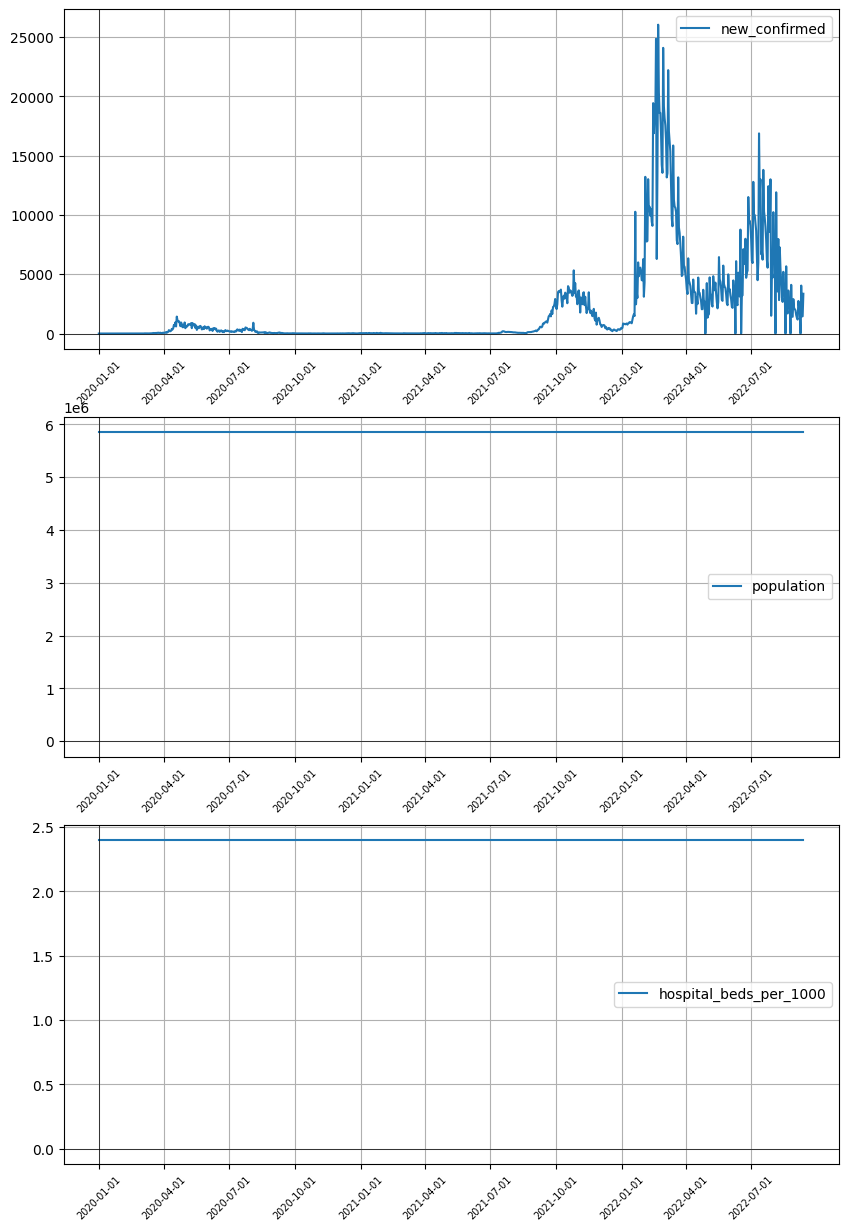

In [13]:
columns_to_plot = [
    "new_confirmed",
    "population",
    "hospital_beds_per_1000"
    
]

fig, axs = plt.subplots(len(columns_to_plot), figsize = (10, 5 * len(columns_to_plot)))



for ax, col_name in zip(axs, columns_to_plot):
    plot_scatter_on_ax(ax, df, col_name)

for ax in axs:
    configure_axis(ax=ax)

In [11]:
from statsmodels.tsa.stattools import grangercausalitytests

In [12]:
grangercausalitytests(df[["search_trends_abdominal_obesity", "search_trends_abdominal_pain"]], maxlag=5)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=115.0561, p=0.0000  , df_denom=982, df_num=1
ssr based chi2 test:   chi2=115.4076, p=0.0000  , df=1
likelihood ratio test: chi2=109.1324, p=0.0000  , df=1
parameter F test:         F=115.0561, p=0.0000  , df_denom=982, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=55.3362 , p=0.0000  , df_denom=979, df_num=2
ssr based chi2 test:   chi2=111.2377, p=0.0000  , df=2
likelihood ratio test: chi2=105.3872, p=0.0000  , df=2
parameter F test:         F=55.3362 , p=0.0000  , df_denom=979, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=31.9461 , p=0.0000  , df_denom=976, df_num=3
ssr based chi2 test:   chi2=96.5257 , p=0.0000  , df=3
likelihood ratio test: chi2=92.0756 , p=0.0000  , df=3
parameter F test:         F=31.9461 , p=0.0000  , df_denom=976, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=22.3616 , p=0.0000  

{np.int64(1): ({'ssr_ftest': (np.float64(115.05612522322836),
    np.float64(1.8455311915178823e-25),
    np.float64(982.0),
    np.int64(1)),
   'ssr_chi2test': (np.float64(115.40762051413436),
    np.float64(6.4075431182619885e-27),
    np.int64(1)),
   'lrtest': (np.float64(109.13239838006712),
    np.float64(1.5180000181372298e-25),
    np.int64(1)),
   'params_ftest': (np.float64(115.0561252232288),
    np.float64(1.8455311915175165e-25),
    np.float64(982.0),
    1.0)},
   array([[0., 1., 0.]])]),
 np.int64(2): ({'ssr_ftest': (np.float64(55.33622294184482),
    np.float64(1.7051033699223228e-23),
    np.float64(979.0),
    np.int64(2)),
   'ssr_chi2test': (np.float64(111.23767798728355),
    np.float64(6.99914732701483e-25),
    np.int64(2)),
   'lrtest': (np.float64(105.38716670072654),
    np.float64(1.3045703965091326e-23),
    np.int64(2)),
   'params_ftest': (np.float64(55.336222941845534),
    np.float64(1.7051033699212445e-23),
    np.float64(979.0),
    2.0)},
   array([